Mean Squared Error: 0.4202795708884784


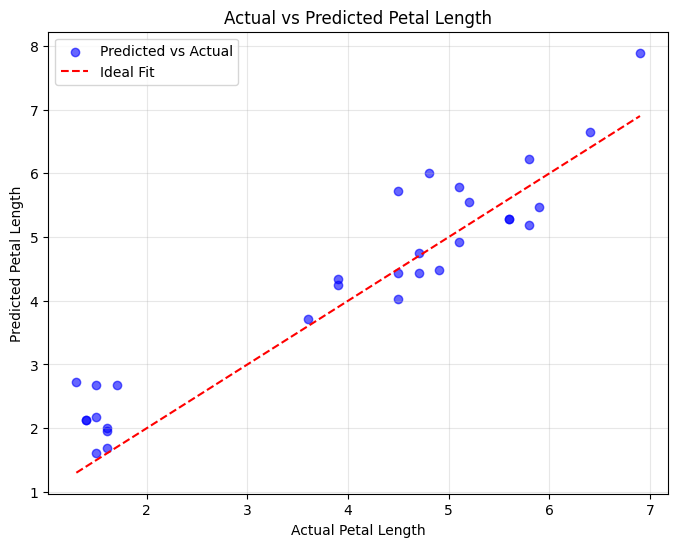

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris_data = pd.read_csv('/content/drive/MyDrive/iris.csv')  # Replace with your file path

# Select features and target
X = iris_data[['sepal_length', 'sepal_width']].values
y = iris_data['petal_length'].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SGD Implementation
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    np.random.seed(42)
    weights = np.random.randn(X.shape[1])  # Initialize weights randomly
    bias = 0  # Initialize bias
    n = len(y)

    for epoch in range(epochs):
        for i in range(n):
            # Randomly pick a single data point (stochastic update)
            idx = np.random.randint(0, n)
            xi = X[idx]
            yi = y[idx]

            # Predict
            prediction = np.dot(xi, weights) + bias

            # Calculate gradient
            error = prediction - yi
            grad_w = 2 * error * xi
            grad_b = 2 * error

            # Update weights and bias
            weights -= learning_rate * grad_w
            bias -= learning_rate * grad_b

    return weights, bias

# Train the model
weights, bias = stochastic_gradient_descent(X_train, y_train, learning_rate=0.01, epochs=1000)

# Predict function
def predict(X, weights, bias):
    return np.dot(X, weights) + bias

# Predict on the test set
y_pred = predict(X_test, weights, bias)

# Calculate Mean Squared Error
mse = np.mean((y_pred - y_test) ** 2)
print(f"Mean Squared Error: {mse}")

# Scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title('Actual vs Predicted Petal Length')
plt.xlabel('Actual Petal Length')
plt.ylabel('Predicted Petal Length')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
